<a href="https://colab.research.google.com/github/JuicyCrab/DPHNN-sf-adr/blob/main/final_SF_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import torch
import seaborn as sns
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torch import nn
import matplotlib.pyplot as plt
import random
import numpy as np

# Data Loading

In [4]:
df = pd.read_csv("content/lorawan_dataset.csv")
df = df.drop(columns=['time', 'device_id'])
df = df.rename(columns={'temperature':'temp', 'SF':'sf'})
df.head()

,co2,humidity,pm25,pressure,temp,rssi,snr,sf,frequency,f_count,p_count,toa,distance,c_walls,w_walls,exp_pl,n_power,esp
0,645.0,54.18,0.32,300.48,23.87,-74.0,12.5,9,867.7,95.0,105.0,0.246784,18,1,2,91.26,-86.737602,-74.237602
1,539.0,49.34,0.39,299.69,24.57,-48.0,8.5,9,867.5,82.0,109.0,0.246784,10,0,0,65.26,-57.073822,-48.573822
2,471.0,45.29,0.32,300.80,25.64,-56.0,12.5,9,867.1,81.0,107.0,0.246784,8,1,0,73.26,-68.737602,-56.237602
3,659.0,49.09,0.44,301.18,24.57,-70.0,9.0,8,868.5,77.0,113.0,0.133632,23,0,2,87.26,-79.514969,-70.514969
4,423.0,38.86,0.13,301.69,27.71,-90.0,11.5,8,867.9,3597.0,4224.0,0.133632,37,0,5,107.26,-101.797062,-90.297062


## Dataset Features

1. **co2**:
- Measured concentration of (CO2) in the environment in parts per million (ppm).
2. **humidity**:
- Relative humidity of the environment, indicating the amount of moisture in the air in %.
3. **pm25**:
- Concentration of particulate matter with a
diameter of less than 2.5 μm in the environment in
micrograms per cubic meter (μg/m3).
4. **pressure**:
- Barometric pressure of the environment in
hectopascals (hPa).
5. **temp**:
- Ambient temperature of the environment
where the measurement was taken in ◦C.
6. **rssi**:
- RSSI at the GW, representing the power level of the
received signal in dB relative to one milliwatt (dBm).
7. **snr**:
- SNR, which compares the desired signal level to the
level of background noise in dB.
8. **SF**:
- SF used in the transmission, determining the
duration of each data symbol and thus the data rate in
bits/symbol.
8. **frequency**:
- Carrier frequency at which the signal was
transmitted in Megahertz (MHz).
9. **f_count**:
- Frame counter used to confirm transmissions
for PDR calculation.
10. **p_count**:
- Count of packets transmitted during the
measurement period for each ED.
11. **toa**:
- Time on Air (ToA), the duration for which the
transmission occupied the channel in seconds (s).
12. **distance**:
- Distance between the GW and the corresponding ED in meters (m).
13. **c_walls**:
- Number of concrete and brick walls between
the ED and GW, affecting signal attenuation.
14. **w_walls**:
- Number of wood partitions between the ED
and GW, affecting signal attenuation.
15. **exp_pl**:
- Experimental path loss, a measure of signal
attenuation over the distance between the transmitter
(TX) and receiver (RX), in dB. It was calculated using
the formula: TPTX (dBm) − CLTX (dB) + GTX (dBi) +GRX (dBi) − CLRX (dB) − RSSI (dBm).
16. **n_power**:
- NP, indicating the strength of the background
interference affecting the received signal in dBm.
17. **esp**:
- The ESP, quantifying the portion of the received
power attributable to the actual signal, excluding
background noise in dBm.

## Data Analysis


In [ ]:
corr_matrix = df.corr()
plt.figure(figsize=(20,20))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='viridis',
    square=True,
    cbar_kws={"shrink": .5}
)

plt.show()

In [ ]:
print(df.info())
print(df[["snr", "toa"]].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1217313 entries, 0 to 1217312
Data columns (total 18 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   co2        1217313 non-null  float64
 1   humidity   1217313 non-null  float64
 2   pm25       1217313 non-null  float64
 3   pressure   1217313 non-null  float64
 4   temp       1217313 non-null  float64
 5   rssi       1217313 non-null  float64
 6   snr        1217313 non-null  float64
 7   sf         1217313 non-null  int64  
 8   frequency  1217313 non-null  float64
 9   f_count    1217313 non-null  float64
 10  p_count    1217313 non-null  float64
 11  toa        1217313 non-null  float64
 12  distance   1217313 non-null  int64  
 13  c_walls    1217313 non-null  int64  
 14  w_walls    1217313 non-null  int64  
 15  exp_pl     1217313 non-null  float64
 16  n_power    1217313 non-null  float64
 17  esp        1217313 non-null  float64
dtypes: float64(14), int64(4)
memory usage: 167

# Hardware Acceleration

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f'CUDA Version: {torch.version.cuda}')

Using device: cuda
GPU Name: NVIDIA GeForce RTX 4060 Ti
CUDA Version: 12.1


# Seeds

In [6]:
np.random.seed(42) # reproducibility
torch.manual_seed(42)
random.seed(42)

# Data Splitting (Both Models)

## Classical ML models

In [7]:
temp_df, m2_test = train_test_split(df, test_size=0.15, random_state=42, stratify=df['sf'])
m1_df, m2_train_df = train_test_split(temp_df, test_size=0.25, random_state=42, stratify=temp_df['sf'])
m1_train, m1_test = train_test_split(m1_df, test_size=0.20, random_state=42, stratify=m1_df['sf'])


features =  ['co2', 'humidity', 'pm25',	'pressure', 'temp',	'rssi', 'sf', 'c_walls', 'w_walls', 'distance']
targets = ['snr', 'toa']

X_m1_train = m1_train[features]
y_m1_train = m1_train[targets]
X_m1_test = m1_test[features]
y_m1_test = m1_test[targets]

# Model 2

X_m2_train = m2_train_df[features]
y_m2_train = m2_train_df[targets]
X_m2_test = m2_test[features]
y_m2_test = m2_test[targets]

## Pytorch Dataset Version


In [8]:
X_m1_tr, X_m1_val, y_m1_tr, y_m1_val = train_test_split(
    X_m1_train, y_m1_train,
    test_size=0.15, random_state=42, stratify=X_m1_train['sf']
)

X_m2_tr, X_m2_val, y_m2_tr, y_m2_val = train_test_split(
    X_m2_train, y_m2_train,
    test_size=0.15, random_state=42, stratify=X_m2_train['sf']
)

# Model 1
X_m1_tr_tensor  = torch.tensor(X_m1_tr.values,  dtype=torch.float32)
y_m1_tr_tensor  = torch.tensor(y_m1_tr.values,  dtype=torch.float32)
X_m1_val_tensor = torch.tensor(X_m1_val.values, dtype=torch.float32)
y_m1_val_tensor = torch.tensor(y_m1_val.values, dtype=torch.float32)
X_m1_test_tensor = torch.tensor(X_m1_test.values, dtype=torch.float32)
y_m1_test_tensor = torch.tensor(y_m1_test.values, dtype=torch.float32)

# Model 2
X_m2_tr_tensor  = torch.tensor(X_m2_tr.values,  dtype=torch.float32)
y_m2_tr_tensor  = torch.tensor(y_m2_tr.values,  dtype=torch.float32)
X_m2_val_tensor = torch.tensor(X_m2_val.values, dtype=torch.float32)
y_m2_val_tensor = torch.tensor(y_m2_val.values, dtype=torch.float32)
X_m2_test_tensor = torch.tensor(X_m2_test.values, dtype=torch.float32)
y_m2_test_tensor = torch.tensor(y_m2_test.values, dtype=torch.float32)


mean_m1 = X_m1_tr_tensor.mean(dim=0)
std_m1  = X_m1_tr_tensor.std(dim=0)
std_m1[std_m1 == 0] = 1


y_mean_m1 = y_m1_tr_tensor.mean(dim=0)
y_std_m1  = y_m1_tr_tensor.std(dim=0)
y_std_m1[y_std_m1 == 0] = 1


mean_m2 = X_m2_tr_tensor.mean(dim=0)
std_m2  = X_m2_tr_tensor.std(dim=0)
std_m2[std_m2 == 0] = 1


torch.save({'mean': mean_m1, 'std': std_m1,
            'y_mean': y_mean_m1, 'y_std': y_std_m1}, 'norm_stats_m1.pt')
torch.save({'mean': mean_m2, 'std': std_m2}, 'norm_stats_m2.pt')


X_m1_tr_tensor   = (X_m1_tr_tensor   - mean_m1) / std_m1
X_m1_val_tensor  = (X_m1_val_tensor  - mean_m1) / std_m1  # same stats as train
X_m1_test_tensor = (X_m1_test_tensor - mean_m1) / std_m1


y_m1_tr_tensor   = (y_m1_tr_tensor   - y_mean_m1) / y_std_m1
y_m1_val_tensor  = (y_m1_val_tensor  - y_mean_m1) / y_std_m1
y_m1_test_tensor = (y_m1_test_tensor - y_mean_m1) / y_std_m1


X_m2_tr_tensor   = (X_m2_tr_tensor   - mean_m2) / std_m2
X_m2_val_tensor  = (X_m2_val_tensor  - mean_m2) / std_m2
X_m2_test_tensor = (X_m2_test_tensor - mean_m2) / std_m2

# Fix: Normalize y_m2 regression targets using Model 1's stats
y_m2_tr_tensor   = (y_m2_tr_tensor   - y_mean_m1) / y_std_m1
y_m2_val_tensor  = (y_m2_val_tensor  - y_mean_m1) / y_std_m1
y_m2_test_tensor = (y_m2_test_tensor - y_mean_m1) / y_std_m1

batch_size = 128

SF_CLASSES = {7.0: 0, 8.0: 1, 9.0: 2, 10.0: 3}

m1_train_dataset = TensorDataset(X_m1_tr_tensor,  y_m1_tr_tensor)
m1_val_dataset   = TensorDataset(X_m1_val_tensor, y_m1_val_tensor)
m1_test_dataset  = TensorDataset(X_m1_test_tensor, y_m1_test_tensor)

m1_train_dataloader = DataLoader(m1_train_dataset, batch_size, shuffle=True)
m1_val_dataloader   = DataLoader(m1_val_dataset,   batch_size)
m1_test_dataloader  = DataLoader(m1_test_dataset,  batch_size, shuffle=False)


y_sf_tr = torch.tensor(X_m2_tr['sf'].map(SF_CLASSES).values, dtype=torch.long)
y_sf_val = torch.tensor(X_m2_val['sf'].map(SF_CLASSES).values, dtype=torch.long)
y_sf_test = torch.tensor(X_m2_test['sf'].map(SF_CLASSES).values, dtype=torch.long)


m2_train_dataset = TensorDataset(X_m2_tr_tensor,  y_m2_tr_tensor, y_sf_tr)
m2_val_dataset   = TensorDataset(X_m2_val_tensor, y_m2_val_tensor, y_sf_val)
m2_test_dataset  = TensorDataset(X_m2_test_tensor, y_m2_test_tensor, y_sf_test)

m2_train_dataloader = DataLoader(m2_train_dataset, batch_size, shuffle=True)
m2_val_dataloader   = DataLoader(m2_val_dataset,   batch_size)
m2_test_dataloader  = DataLoader(m2_test_dataset,  batch_size, shuffle=False)

# Model 1 (Predicting SNR/TOA)

## Evals

In [46]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_regression_model(model, X, y_true, data_name="Validation"):
    predictions = model.predict(X)

    # Evaluate SNR
    mse_snr = mean_squared_error(y_true['snr'], predictions[:, 0])
    rmse_snr = np.sqrt(mse_snr)
    r2_snr = r2_score(y_true['snr'], predictions[:, 0])

    # Evaluate ToA
    mse_toa = mean_squared_error(y_true['toa'], predictions[:, 1])
    rmse_toa = np.sqrt(mse_toa)
    r2_toa = r2_score(y_true['toa'], predictions[:, 1])

    print(f"\n--- {data_name} Set Evaluation ---")
    print(f"SNR - MSE: {mse_snr:.4f}, RMSE: {rmse_snr:.4f}, R-squared: {r2_snr:.4f}")
    print(f"ToA - MSE: {mse_toa:.4f}, RMSE: {rmse_toa:.4f}, R-squared: {r2_toa:.4f}")

    return {"snr_rmse": rmse_snr, "toa_rmse": rmse_toa}

## Random Forest

In [49]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
}


rf = RandomForestRegressor(random_state=42, n_jobs=None)

grid_search_rf = RandomizedSearchCV(estimator=rf, param_distributions=param_grid_rf,
                                    cv=3, n_jobs=None, verbose=2, scoring='neg_mean_squared_error')

grid_search_rf.fit(X_m1_train, y_m1_train)
print("Random Forest complete.")

best_rf_model = grid_search_rf.best_estimator_

print(f"\nBest parameters for Random Forest: {grid_search_rf.best_params_}")


print("\nEvaluating Best Random Forest Model on Test Set...")
evaluate_regression_model(best_rf_model, X_m1_test, y_m1_test, data_name="Best Random Forest Test")

c:\Users\eyasu\dev\.venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV] END .....................max_depth=10, n_estimators=100; total time= 1.3min
[CV] END .....................max_depth=10, n_estimators=100; total time= 1.3min
[CV] END .....................max_depth=10, n_estimators=100; total time= 1.3min
[CV] END .....................max_depth=10, n_estimators=200; total time= 2.5min
[CV] END .....................max_depth=10, n_estimators=200; total time= 2.5min
[CV] END .....................max_depth=10, n_estimators=200; total time= 2.5min
[CV] END .....................max_depth=10, n_estimators=300; total time= 3.8min
[CV] END .....................max_depth=10, n_estimators=300; total time= 3.8min
[CV] END .....................max_depth=10, n_estimators=300; total time= 3.8min
[CV] END .....................max_depth=20, n_estimators=100; total time= 2.3min
[CV] END .....................max_depth=20, n_estimators=100; total time= 2.3min
[CV] END .....................max_depth=20, n_est

{'snr_rmse': np.float64(1.6280715865441007),
 'toa_rmse': np.float64(0.01219530040838897)}

## XGBoost

In [ ]:
from xgboost import XGBRegressor
param_grid_xgb = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}


xgb = XGBRegressor(random_state=42, tree_method='hist', n_jobs=-1)


grid_search_xgb = GridSearchCV(estimator=xgb, param_grid=param_grid_xgb,
                               cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')


grid_search_xgb.fit(X_m1_train, y_m1_train)
print("XGBoost complete.")


best_xgb_model = grid_search_xgb.best_estimator_

print(f"\nBest parameters for XGBoost: {grid_search_xgb.best_params_}")

print("\nEvaluating Best XGBoost Model on Test Set...")
evaluate_regression_model(best_xgb_model, X_m1_test, y_m1_test, data_name="Best XGBoost Test")


Fitting 3 folds for each of 32 candidates, totalling 96 fits
XGBoost complete.

Best parameters for XGBoost: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.7}

Evaluating Best XGBoost Model on Test Set...

--- Best XGBoost Test Set Evaluation ---
SNR - MSE: 2.9419, RMSE: 1.7152, R-squared: 0.7696
ToA - MSE: 0.0000, RMSE: 0.0016, R-squared: 0.9999


{'snr_rmse': np.float64(1.715207092370147),
 'toa_rmse': np.float64(0.001598441570029071)}

## Basic Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression(n_jobs=-1)

print("Training Linear Regression Model...")
lr_model.fit(X_m1_train, y_m1_train)
print("Linear Regression Model training complete.")

# Evaluate on Test Set
lr_test_metrics = evaluate_regression_model(lr_model, X_m1_test, y_m1_test, data_name="Linear Regression Test")

Training Linear Regression Model...
Linear Regression Model training complete.

--- Linear Regression Test Set Evaluation ---
SNR - MSE: 6.9693, RMSE: 2.6399, R-squared: 0.4543
ToA - MSE: 0.0013, RMSE: 0.0362, R-squared: 0.9362


## Neural Network(MLP)

### Architecture

In [9]:
class SnrToaNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.backbone = nn.Sequential(
            nn.Linear(10, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
        )

    self.snr_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    self.toa_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
  def forward(self, x):
    shared = self.backbone(x)
    return self.snr_head(shared), self.toa_head(shared)

mlp_snr_toa_model = SnrToaNetwork().to(device)
print(mlp_snr_toa_model)

SnrToaNetwork(
  (backbone): Sequential(
    (0): Linear(in_features=10, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): ReLU()
  )
  (snr_head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (toa_head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)


### Loss and Optimizer

In [10]:
loss_fn = nn.MSELoss()
optimizers = {
    'SGD': torch.optim.SGD(mlp_snr_toa_model.parameters(), lr=1e-3),
    'Adam': torch.optim.Adam(mlp_snr_toa_model.parameters(), lr=1e-3, weight_decay=0.001),
    'AdamW': torch.optim.AdamW(mlp_snr_toa_model.parameters(), lr=1e-3, weight_decay=1e-3)
}
optimizer = optimizers['AdamW']

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=8, factor=0.5
)

### Helper Functions

In [9]:
def train(dataloader, model, loss_fn, optimizer):
  size = len(dataloader.dataset)
  total_loss = 0
  num_batches = len(dataloader)
  model.train()
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    snr_pred, toa_pred = model(X)

    # Calculate loss for SNR and ToA separately
    loss_snr = loss_fn(snr_pred, y[:, 0].unsqueeze(1)) # unsqueeze to match (batch_size, 1) shape
    loss_toa = loss_fn(toa_pred, y[:, 1].unsqueeze(1))

    loss = loss_snr + loss_toa # Combine losses

    #backpropagation
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    total_loss += loss.item() #converts tensor into python float and ensures to not grab the whole graph from memory
    if batch % 100 == 0:
      loss, current = loss.item(), (batch + 1) * len(X)
      print(f"train loss: {loss} [{current:>5d}/{size:>5d}]")
  return total_loss / num_batches

In [11]:
def val(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    val_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            snr_pred, toa_pred = model(X)

            loss_snr = loss_fn(snr_pred, y[:, 0].unsqueeze(1))
            loss_toa = loss_fn(toa_pred, y[:, 1].unsqueeze(1))

            val_loss += (loss_snr + loss_toa).item()

    val_loss /= num_batches
    return val_loss

In [ ]:
epochs = 200
train_losses, val_losses = [], []
for t in range(epochs):
  train_loss = train(m1_train_dataloader, mlp_snr_toa_model, loss_fn, optimizer)
  val_loss = val(m1_val_dataloader, mlp_snr_toa_model, loss_fn)
  scheduler.step(val_loss)
  train_losses.append(train_loss)
  val_losses.append(val_loss)
  if (t + 1) % 10 == 0:
      print(f"----- Epoch {t+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} -----")

### Loss Graph

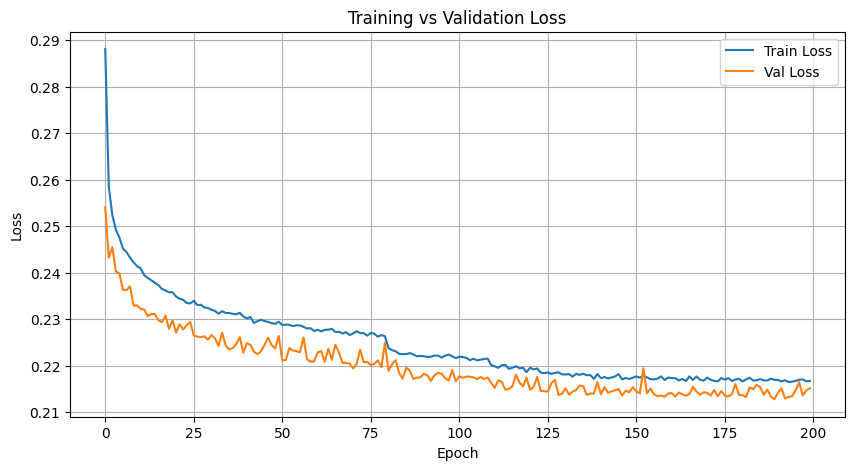

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# MLP Evaluations

In [11]:
from sklearn.metrics import r2_score

def mlp_eval(model, dataloader, y_std, device):
    model.eval()
    all_snr_preds = []
    all_toa_preds = []
    all_targets = []

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            y = y.view(-1, 2)
            snr_pred, toa_pred = model(X) # Unpack the tuple here
            all_snr_preds.append(snr_pred)
            all_toa_preds.append(toa_pred)
            all_targets.append(y)

    preds_snr = torch.cat(all_snr_preds, dim=0)
    preds_toa = torch.cat(all_toa_preds, dim=0)
    preds = torch.cat((preds_snr, preds_toa), dim=1) # Combine snr and toa predictions into a single tensor

    targets = torch.cat(all_targets, dim=0)

    #undo normalization
    y_mean_device = y_mean_m1.to(device)
    y_std_device = y_std.to(device)

    preds_denorm = (preds * y_std_device) + y_mean_device
    targets_denorm = (targets * y_std_device) + y_mean_device

    mse_per_output = ((preds_denorm - targets_denorm) ** 2).mean(dim=0)
    rmse_per_output = torch.sqrt(mse_per_output)

    r2_snr = r2_score(targets_denorm[:, 0].cpu().numpy(), preds_denorm[:, 0].cpu().numpy())
    r2_toa = r2_score(targets_denorm[:, 1].cpu().numpy(), preds_denorm[:, 1].cpu().numpy())

    print(f"SNR  RMSE: {rmse_per_output[0].item():.4f}")
    print(f"ToA  RMSE: {rmse_per_output[1].item():.4f}")
    print(f"SNR  MSE: {mse_per_output[0].item():.4f}")
    print(f"ToA  MSE: {mse_per_output[1].item():.10f}")
    print(f"SNR  R-squared: {r2_snr:.4f}")
    print(f"ToA  R-squared: {r2_toa:.4f}")
    return mse_per_output

In [12]:
# rmse = rmse_eval(model, val_dataloader, y_std, device)
rmse_test = mlp_eval(mlp_snr_toa_model, m1_test_dataloader, y_std_m1, device)

SNR  RMSE: 3.5819
ToA  RMSE: 0.1429
SNR  MSE: 12.8300
ToA  MSE: 0.0204280838
SNR  R-squared: -0.0079
ToA  R-squared: 0.0027


### Saving Model Architecture

In [16]:
model_save_path = 'best_snr_toa_neural_net.pt'

In [17]:
torch.save(mlp_snr_toa_model.state_dict(), model_save_path)
print(f"Best MLP model weights saved to {model_save_path}")

Best MLP model weights saved to best_snr_toa_neural_net.pt


# Model 2 (Spreading Factor Prediction)

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

### SGD Classifier

In [ ]:
sgd_param_grid = {
    'sgdclassifier__loss': ['hinge', 'log_loss'],
    'sgdclassifier__penalty': ['l1', 'l2', 'elasticnet'],
    'sgdclassifier__alpha': [0.0001, 0.001, 0.01],
    'sgdclassifier__max_iter': [1000],
    'sgdclassifier__learning_rate': ['optimal', 'adaptive'],
    'sgdclassifier__eta0': [0.01]
}

pipe = make_pipeline(StandardScaler(), SGDClassifier(tol=1e-3, early_stopping=True, random_state=42, class_weight='balanced'))
sgd_search = GridSearchCV(pipe, param_grid=sgd_param_grid,  cv=3)

### Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rnd_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True]
}

In [ ]:
rnd_clf = RandomForestClassifier(random_state=42)
rnd_grid = GridSearchCV(param_grid=rnd_param_grid, estimator=rnd_clf, cv=3, n_jobs=-1)

## Neural Net

In [14]:
class SFNeuralNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.arch = nn.Sequential(
        nn.Linear(10, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 4)
    )

  def forward(self, x):
    return self.arch(x)

mlp_sf_model = SFNeuralNet().to(device)
print(mlp_sf_model)

SFNeuralNet(
  (arch): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=4, bias=True)
  )
)


### Load Model 1 SNR and TOA Predictor

In [ ]:
model_save_path = 'best_snr_toa_neural_net.pt'
loaded_norm_stats = torch.load('norm_stats_m2.pt')
loaded_model_2_mean = loaded_norm_stats['mean']
loaded_model_2_std = loaded_norm_stats['std']
loaded_sf_mean = loaded_model_2_mean[6].to(device)
loaded_sf_std = loaded_model_2_std[6].to(device)
loaded_mlp_model = SnrToaNetwork().to(device)

loaded_mlp_model.load_state_dict(torch.load(model_save_path, map_location=torch.device('cpu')))
loaded_mlp_model.eval()

print("MLP model loaded for inference.")

# Dual-Path Hybrid Neural Network

In [ ]:
# X_m1['co2', 'humidity', 'pm25',	'pressure', 'temp',	'rssi', 'sf', 'c_walls', 'w_walls', 'distance']
# -> model 1 -> toa,snr ->> model 2[toa, snr, env] -> sf_pred -> model 1 -> snr_pred, toa_pred
# -> loss_func(snr_pred, toa_pred, toa_dataset, snr_dataset) -> repeat
# Need to save the snr and toa values from the dataset | y_labels = snr, toa

In [16]:
SF_VALUES = torch.tensor([7.0, 8.0, 9.0, 10.0], device=device)
sf_loss_fn = nn.CrossEntropyLoss()

In [17]:
def train_DPHNN(dataloader, model_1, model_2, loss_fn, sf_loss_fn, optimizer, device, y_mean, y_std):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    total_loss = 0

    #feature indicies = [co2, humidity, pm25, pressure, temp, rssi, sf, c_walls, w_walls, distance]
    first_m1_idx = list(range(10))
    second_m1_idx = [0,1,2,3,4,5,7,8,9]
    m2_idx = [0,1,2,3,4,7,8,9]


    model_1.requires_grad_(False) #model_1 wieghts don't get changed
    model_2.train()
    for batch, (X, y_reg, y_sf) in enumerate(dataloader):
      X, y_reg, y_sf = X.to(device), y_reg.to(device), y_sf.to(device)

      with torch.no_grad(): #pure inference no gradient graph is needed
        snr_first_pred, toa_first_pred = model_1(X[:, first_m1_idx])

      m2_input = torch.cat([
          X[:, m2_idx],
          snr_first_pred,
          toa_first_pred
      ], dim=1)

      sf_logits = model_2(m2_input)
      sf_probs = torch.softmax(sf_logits, dim=1)
      sf_soft = (sf_probs * SF_VALUES).sum(dim=1, keepdim=True) #computed the weighted sum(expected value)
      sf_soft = (sf_soft - y_mean) / y_std #normalize sf for model 1 input
      sf_soft = (sf_soft - y_mean) / y_std 
      m1_second_input = torch.cat([X[:, second_m1_idx], sf_soft], dim=1)

      loss_sf = sf_loss_fn(sf_logits, y_sf)
      snr_second_pred, toa_second_pred = model_1(m1_second_input)

      loss_snr = loss_fn(snr_second_pred, y_reg[:, 0].unsqueeze(1))
      loss_toa = loss_fn(toa_second_pred, y_reg[:, 1].unsqueeze(1))
      alpha = 0.9
      beta = 0.2 
      loss = alpha * loss_toa + beta * loss_sf

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      total_loss += loss.item()
      if batch % 100 == 0:
        current = (batch + 1) * len(X)
        print(f"train loss: {loss.item():>4f} [{current:>5d}/{size:>5d}]")
    return total_loss / num_batches

In [29]:
def val_DPHNN(dataloader, model_1, model_2, loss_fn, sf_loss_fn, device, y_mean, y_std):
  num_batches = len(dataloader)
  val_loss = 0

  first_m1_idx = list(range(10))
  second_m1_idx = [0,1,2,3,4,5,7,8,9]
  m2_idx = [0,1,2,3,4,7,8,9]

  model_1.requires_grad_(False)
  model_2.eval()

  with torch.no_grad():
    for batch, (X, y_reg, y_sf) in enumerate(dataloader):
        X, y_reg, y_sf = X.to(device), y_reg.to(device), y_sf.to(device)

        snr_first_pred, toa_first_pred = model_1(X[:, first_m1_idx])
        m2_input = torch.cat([X[:, m2_idx], snr_first_pred, toa_first_pred], dim=1)
        sf_logits = model_2(m2_input)

        sf_indices = torch.argmax(sf_logits, dim=1)
        sf_pred = SF_VALUES[sf_indices].unsqueeze(1)
        sf_pred = (sf_pred - y_mean) / y_std 
        m1_second_input = torch.cat([X[:, second_m1_idx], sf_pred], dim=1)
        snr_second_pred, toa_second_pred = model_1(m1_second_input)

        loss_snr = loss_fn(snr_second_pred, y_reg[:, 0].unsqueeze(1))
        loss_toa = loss_fn(toa_second_pred, y_reg[:, 1].unsqueeze(1))
        loss_sf = sf_loss_fn(sf_logits, y_sf)

        val_loss += (loss_snr + loss_toa + loss_sf).item()

  val_loss /= num_batches
  return val_loss

In [ ]:
epochs = 200
m2_train_losses, m2_val_losses = [], []
for t in range(epochs):
  m2_train_loss = train_DPHNN(m2_train_dataloader, loaded_mlp_model, mlp_sf_model, loss_fn, sf_loss_fn, optimizer, device, loaded_sf_mean, loaded_sf_std)
  m2_val_loss = val_DPHNN(m2_val_dataloader, loaded_mlp_model, mlp_sf_model, loss_fn, sf_loss_fn, device, loaded_sf_mean, loaded_sf_std)
  scheduler.step(m2_val_loss)
  m2_train_losses.append(m2_train_loss)
  m2_val_losses.append(m2_val_loss)
  if (t + 1) % 10 == 0:
      print(f"----- Epoch {t+1}/{epochs} | Train Loss: {m2_train_loss:.4f} | Val Loss: {m2_val_loss:.4f} -----")

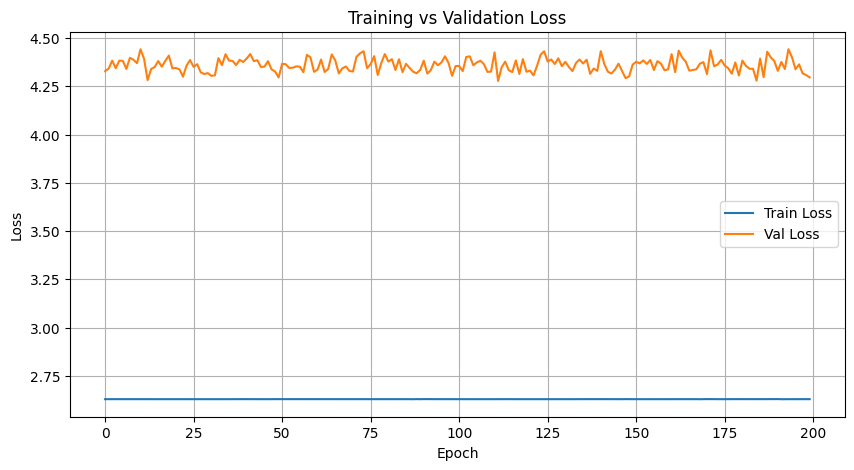

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(m2_train_losses, label='Train Loss')
plt.plot(m2_val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()